# Twitter Sentiment Analysis

This notebook builds and trains a sentiment classifier on tweets. It is the modeling half of a project whose other half is a REST API that serves the trained model through a `POST /evaluate` endpoint.

## Goal

Train a model that takes a sentence and returns its sentiment, exposed through two core functions:

- **`train`**: fits the classifier on the labeled training data.
- **`evaluate`**: takes one input sentence and returns its predicted sentiment.

The emphasis is on clear, well-reasoned modeling decisions and clean, maintainable code rather than state-of-the-art accuracy.

## Dataset

[Sentiment140](http://help.sentiment140.com/for-students) (Go, Bhayani & Huang, 2009). Each row has six columns: polarity, tweet ID, date, query, user, and text.

| File | Rows | Labels |
|---|---|---|
| `training.1600000.processed.noemoticon.csv` | 1,600,000 | 800k negative (`0`), 800k positive (`4`) |
| `testdata.manual.2009.06.14.csv` | 498 | 177 negative (`0`), 139 neutral (`2`), 182 positive (`4`) |

The training labels were assigned automatically from emoticons, which were then stripped from the text, so they are noisy. The test set was labeled by hand and includes a **neutral** class that never appears in training. How to handle that mismatch is a decision addressed later in the notebook.

## Outline

1. Setup and data loading
2. Exploratory data analysis
3. Preprocessing
4. Model: encoding method and classifier
5. Training (`train`)
6. Evaluation on the test set
7. Inference (`evaluate`)
8. Discussion: design choices and comparison with other approaches

In [25]:
import pandas as pd

import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

pd.set_option("display.max_colwidth", None)

In [7]:
from pathlib import Path

import pandas as pd

DATA_DIR = Path("trainingandtestdata")
TRAIN_PATH = DATA_DIR / "training.1600000.processed.noemoticon.csv"
TEST_PATH = DATA_DIR / "testdata.manual.2009.06.14.csv"

COLUMNS = ["polarity", "id", "date", "query", "user", "text"]
LABELS = {0: "negative", 2: "neutral", 4: "positive"}


def load_tweets(path: Path) -> pd.DataFrame:
    """Load a Sentiment140 CSV with all columns plus a readable sentiment label."""
    df = pd.read_csv(
        path,
        header=None,          # the files have no header row
        names=COLUMNS,
        encoding="latin-1",   # the training file has bytes that aren't valid UTF-8
    )
    df["label"] = df["polarity"].map(LABELS)
    return df


train_df = load_tweets(TRAIN_PATH)
test_df = load_tweets(TEST_PATH)


In [12]:
pd.set_option("display.max_colwidth", None)
print(train_df.shape, test_df.shape)
print(train_df["label"].value_counts())
print(test_df["label"].value_counts())
train_df.head(20)



(1600000, 7) (498, 7)
label
negative    800000
positive    800000
Name: count, dtype: int64
label
positive    182
negative    177
neutral     139
Name: count, dtype: int64


,polarity,id,date,query,user,text,label
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D",negative
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!,negative
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds,negative
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,negative
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there.",negative
5,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,negative
6,0,1467811592,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,mybirch,Need a hug,negative
7,0,1467811594,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,coZZ,"@LOLTrish hey long time no see! Yes.. Rains a bit ,only a bit LOL , I'm fine thanks , how's you ?",negative
8,0,1467811795,Mon Apr 06 22:20:05 PDT 2009,NO_QUERY,2Hood4Hollywood,@Tatiana_K nope they didn't have it,negative
9,0,1467812025,Mon Apr 06 22:20:09 PDT 2009,NO_QUERY,mimismo,@twittera que me muera ?,negative


In [19]:
positive_df = train_df[train_df["label"] == "positive"]
pd.set_option("display.max_colwidth", None)
positive_df.head(15)

,polarity,id,date,query,user,text,label
800000,4,1467822272,Mon Apr 06 22:22:45 PDT 2009,NO_QUERY,ersle,I LOVE @Health4UandPets u guys r the best!!,positive
800001,4,1467822273,Mon Apr 06 22:22:45 PDT 2009,NO_QUERY,becca210,im meeting up with one of my besties tonight! Cant wait!! - GIRL TALK!!,positive
800002,4,1467822283,Mon Apr 06 22:22:46 PDT 2009,NO_QUERY,Wingman29,"@DaRealSunisaKim Thanks for the Twitter add, Sunisa! I got to meet you once at a HIN show here in the DC area and you were a sweetheart.",positive
800003,4,1467822287,Mon Apr 06 22:22:46 PDT 2009,NO_QUERY,katarinka,"Being sick can be really cheap when it hurts too much to eat real food Plus, your friends make you soup",positive
800004,4,1467822293,Mon Apr 06 22:22:46 PDT 2009,NO_QUERY,_EmilyYoung,@LovesBrooklyn2 he has that effect on everyone,positive
800005,4,1467822391,Mon Apr 06 22:22:47 PDT 2009,NO_QUERY,ajarofalmonds,@ProductOfFear You can tell him that I just burst out laughing really loud because of that Thanks for making me come out of my sulk!,positive
800006,4,1467822447,Mon Apr 06 22:22:51 PDT 2009,NO_QUERY,vmdavinci,@r_keith_hill Thans for your response. Ihad already find this answer,positive
800007,4,1467822465,Mon Apr 06 22:22:48 PDT 2009,NO_QUERY,jessicavaliyi,"@KeepinUpWKris I am so jealous, hope you had a great time in vegas! how did you like the ACM's?! LOVE YOUR SHOW!!",positive
800008,4,1467822489,Mon Apr 06 22:22:49 PDT 2009,NO_QUERY,emmasaur28,"@tommcfly ah, congrats mr fletcher for finally joining twitter",positive
800009,4,1467822496,Mon Apr 06 22:22:49 PDT 2009,NO_QUERY,SherylBreuker,@e4VoIP I RESPONDED Stupid cat is helping me type. Forgive errors,positive


In [ ]:
train_df["query"].unique()
train_df["polarity"].unique()


array([0, 4])

**Data Exploration**

In [ ]:
# sample 
# this picks 100,000 random rows and random state locks these rows in 
# value counts shows how many positive and negative values there are in the sample dataset
SEED = 42
SAMPLE_SIZE = 100_000

# A random sample keeps the slower cells fast. The training file is sorted by
# label, so a random sample is needed to get both classes (.head() would give only negatives).
sample_df = train_df.sample(n=SAMPLE_SIZE, random_state=SEED)
sample_df["label"].value_counts()

label
positive    50057
negative    49943
Name: count, dtype: int64

**1. Data Structure and Quality**

In [26]:
print("Missing values (train):")
print(train_df.isna().sum(), end="\n\n")
print("Missing values (test):")
print(test_df.isna().sum())


Missing values (train):
polarity    0
id          0
date        0
query       0
user        0
text        0
label       0
dtype: int64

Missing values (test):
polarity    0
id          0
date        0
query       0
user        0
text        0
label       0
dtype: int64


In [ ]:
# relabel the text here so it's less AI 
n_extra_copies = train_df.duplicated(subset="text").sum()
duplicated_texts = train_df[train_df.duplicated(subset="text", keep=False)]
labels_per_text = duplicated_texts.groupby("text")["label"].nunique()
conflicting_texts = labels_per_text[labels_per_text > 1].index

print(f"Extra copies of an already-seen text: {n_extra_copies:,} ({n_extra_copies / len(train_df):.2%})")
print(f"Distinct texts that appear more than once: {len(labels_per_text):,}")
print(f"...of which appear with BOTH labels: {len(conflicting_texts):,}")
print(f"Duplicate tweet IDs: {train_df['id'].duplicated().sum():,}")


Extra copies of an already-seen text: 18,534 (1.16%)
Distinct texts that appear more than once: 8,434
...of which appear with BOTH labels: 2,225
Duplicate tweet IDs: 1,685


In [46]:
# Examples of the same text labeled both positive and negative
train_df[train_df["text"].isin(conflicting_texts[:10])].sort_values("text")[["text", "label"]]

,text,label
1394129,"British weather is back i see! Oh well Birtney, london and ciaraaaa in 5 dayssss",positive
385331,"British weather is back i see! Oh well Birtney, london and ciaraaaa in 5 dayssss",negative
1272390,I love you,positive
507399,I love you,negative
1077756,"Raining tomorrow afternoon but its going to be very nice at 5 59! ! Hope it changes, I want it to be nicee in the afternoon&amp;nitee!",positive
184535,"Raining tomorrow afternoon but its going to be very nice at 5 59! ! Hope it changes, I want it to be nicee in the afternoon&amp;nitee!",negative
730048,That is all.,negative
1030537,That is all.,positive
118605,Uhm.. science! -.- Verrrry boring and LONG Grrr.,negative
968532,Uhm.. science! -.- Verrrry boring and LONG Grrr.,positive


In [29]:
# The most-repeated texts (spam or bot accounts tend to show up here)
duplicated_texts["text"].value_counts().head(10)


text
isPlayer Has Died! Sorry                                                                          210
good morning                                                                                      118
headache                                                                                          115
Good morning                                                                                      112
Headache                                                                                          106
 cant afford to see Angels and Demons, so i watched it for free: http://tr.im/lvBu                 86
Not to worry, noone got that one. Next question starts in 1 minute, get your thinking caps on      86
Goodnight                                                                                          85
my tummy hurts                                                                                     81
Jogging, isnt REALLY that cool, especially if you've got a fever             

**2. Text Length**

In [30]:
def add_length_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Add character and whitespace-separated word counts for each tweet."""
    return df.assign(
        n_chars=df["text"].str.len(),
        n_words=df["text"].str.split().str.len(),
    )


train_df = add_length_columns(train_df)
test_df = add_length_columns(test_df)

train_df.groupby("label")[["n_chars", "n_words"]].describe().T


label               negative       positive
n_chars count  800000.000000  800000.000000
        mean       74.301790      73.878433
        std        36.743260      36.135274
        min         6.000000       6.000000
        25%        44.000000      44.000000
        50%        70.000000      69.000000
        75%       104.000000     103.000000
        max       359.000000     374.000000
n_words count  800000.000000  800000.000000
        mean       13.581984      12.770318
        std         7.073519       6.816371
        min         1.000000       1.000000
        25%         8.000000       7.000000
        50%        13.000000      12.000000
        75%        19.000000      18.000000
        max        57.000000      64.000000

In [31]:
print(f"Tweets over 140 characters: {(train_df['n_chars'] > 140).sum():,}")
print(f"Tweets with 1 word or fewer: {(train_df['n_words'] <= 1).sum():,}")
print(f"95th / 99th percentile word count: {train_df['n_words'].quantile([0.95, 0.99]).tolist()}")

# Tweets were capped at 140 characters, so longer ones point to a data issue
train_df.loc[train_df["n_chars"] > 140, "text"].head(5)


Tweets over 140 characters: 17,174
Tweets with 1 word or fewer: 5,978
95th / 99th percentile word count: [25.0, 28.0]


213       Awwh babs... you look so sad underneith that shop entrance of &quot;Yesterday's Musik&quot;  O-: I like the look of the new transformer movie 
226        Tuesdayï¿½ll start with reflection ï¿½n then a lecture in Stress reducing techniques. That sure might become very useful for us accompaniers 
279    Whinging. My client&amp;boss don't understand English well. Rewrote some text unreadable. It's written by v. good writer&amp;reviewed correctly. 
343    @TheLeagueSF Not Fun &amp; Furious? The new mantra for the Bay 2 Breakers? It was getting 2 rambunctious;the city overreacted &amp; clamped down 
400     #3 woke up and was having an accident - &quot;It's pushing, it's pushing!&quot; he was crying because he couldn't stop from wetting his pants.  
Name: text, dtype: str

In [ ]:
train_df.loc[train_df["n_words"] <= 1, ["text", "label"]].sample(10, random_state=SEED)

,text,label
436674,grounded,negative
548057,@Rad_Wolf,negative
845052,Shweeep.,positive
307075,@youcancallmeali,negative
1210429,www.reinventons.be,positive
323001,unpacking,negative
488376,Raining,negative
440974,@thenamesmary,negative
20870,@blazersedge,negative
1094970,picture,positive


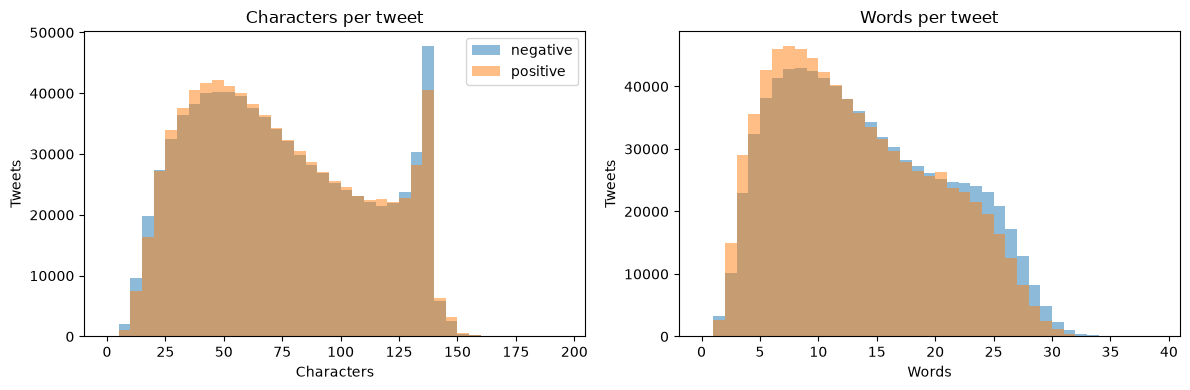

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, group in train_df.groupby("label"):
    axes[0].hist(group["n_chars"], bins=range(0, 200, 5), alpha=0.5, label=label)
    axes[1].hist(group["n_words"], bins=range(0, 40), alpha=0.5, label=label)
axes[0].set(title="Characters per tweet", xlabel="Characters", ylabel="Tweets")
axes[1].set(title="Words per tweet", xlabel="Words", ylabel="Tweets")
axes[0].legend()
plt.tight_layout()
plt.show()


**3. Reading the tweets**

In [34]:
def show_examples(df: pd.DataFrame, label: str, n: int = 20, seed: int = SEED) -> None:
    """Print a random sample of tweets with the given label, one per line."""
    texts = df.loc[df["label"] == label, "text"].sample(n, random_state=seed)
    for text in texts:
        print("-", text)


show_examples(sample_df, "positive")


- @mikasounds It's killing me that I can't go, but the videos I've seen from the gigs are absolutly phenomenal. I'm happy for you 
- The Ginger is appearing back in my hair again  and I'm so so happy right now  and I'm wearing my Spurs shirt! Pretty goood  x
- @carocat Hi Cat 
- have to go to our summer cottage, gonna be there the whole day.. no twitter byhyhyy :/  byebye!
- @donniewahlberg block fans get it more than anybody because you guys GIVE more than anybody! we are the lucky ones! LOVE YOU! XXOO 
- @LenoreHuynh Don't thank me boo,  just keep it up miss independent   Hope you have a blessed day Tweetheart lol
- @jalopnik Done! And you're my first Digg 
- How to win real prizes for your photos http://www.outfitlandia.com. Flickr meets Twitter meets Italian designers 
- Good am! Just slept for 4 hours.. I need to sleep! 
- @pftittl if it weren't for that tip I would have no way of knowing which tweet you were okaying 
- *flails* I missed the first 12 minutes of I'm  Patti Blagojev

In [ ]:
show_examples(sample_df, "negative")
# To see different tweets, run these again with a different seed. While reading, keep count of how many labels you disagree with.

- @CocoaGeek Hope not  My first app, and our longest approval ever.
- FALLING IN LOVE NO LIVE AT WEMBLEY NAAAAAAAAAAAAAAO 
- While we are on the rain subject I fuckin hate this rain! I need to do a soil test and can't with this damn weather! 
- last day at work today 
- back in bed 
- Stuck in traffic because of road work! 
- Endevour launch scrubbed again for hydrogen leak   http://bit.ly/2PALa
- missed Singin Phillip at Hardrock  now i have to figure out how to back out of my VIP parking space lol
- i want the sims 3 
- I want to go to another country, I find USA to be so boring right now 
- Sars epic balloon fail  http://twitpic.com/68uth
- my tummy hurts so much 
- I wish I could find more than 3 people on here that I know!  And I wish my background picture woud upload right...
- Neb treatment number 4 this evening....this isnt looking so good for Zoie. 
- My God I really love my big sister. I miss her. 
- @deanomeano yes, sucks big time  I'm almost tempted to plan a holiday to the

In [36]:
TEXT_PATTERNS = {
    "@mention": r"@\w+",
    "url": r"https?://\S+|www\.\S+",
    "hashtag": r"#\w+",
    "html_entity": r"&(?:amp|quot|lt|gt);",
    "repeated_letters": r"(\w)\1{2,}",
    "all_caps_word": r"\b[A-Z]{3,}\b",
    "encoding_error": r"Ã|Â|â|ï¿½",
}

# Percentage of tweets in each class that contain each pattern.
# (.str.count(...).gt(0) avoids a pandas warning about the capture group in repeated_letters)
pattern_rates = (
    pd.DataFrame({
        name: sample_df["text"].str.count(pattern).gt(0)
        for name, pattern in TEXT_PATTERNS.items()
    })
    .groupby(sample_df["label"])
    .mean()
    .T
)
(pattern_rates * 100).round(1)


label,negative,positive
@mention,37.6,54.8
url,3.2,6.4
hashtag,1.9,2.6
html_entity,4.9,7.1
repeated_letters,9.4,9.4
all_caps_word,10.7,12.2
encoding_error,0.7,1.0


In [37]:
# A few examples of each pattern, to see what you'd be cleaning
for name in ["html_entity", "encoding_error", "repeated_letters"]:
    print(f"\n{name}:")
    matches = sample_df.loc[sample_df["text"].str.count(TEXT_PATTERNS[name]).gt(0), "text"]
    for text in matches.head(3):
        print("-", text)



html_entity:
- No woooooork tomorrrow&amp;tuesday 
- @Konstantine I said &quot;scar,&quot; sweetie. 
- just back from SuperCheap - a most successful trip. The bikes are tanked &amp; checked for the week, so all ready to start relaxing 

encoding_error:
- FCK-Brï¿½ndby 4-0! 
- at school...listining to die Ãrzte - Westerland...great song really..btw i'm so tired...i sleeped between 02:30 and 05:30..thats bad 
- blÃ¤Ã¤ i have a headache 

repeated_letters:
- @chrishasboobs AHHH I HOPE YOUR OK!!! 
- Working on photos from Hillsong's 1 year celebration!!! stay tuned   www.hillsong.co.za
- No woooooork tomorrrow&amp;tuesday 


**4. Vocabulary by class**

In [38]:
NOISE_PATTERN = re.compile(r"@\w+|https?://\S+|www\.\S+|&\w+;")
TOKEN_PATTERN = re.compile(r"[a-z']+")


def tokenize(text: str) -> list[str]:
    """Lowercase, drop mentions/URLs/HTML entities, and split into word tokens.

    Only used for exploration, not for the model.
    """
    text = NOISE_PATTERN.sub(" ", text.lower())
    return TOKEN_PATTERN.findall(text)


word_counts = {
    label: Counter(token for text in group["text"] for token in tokenize(text))
    for label, group in sample_df.groupby("label")
}

for label, counts in word_counts.items():
    print(f"{label}: {counts.most_common(15)}")


negative: [('i', 29943), ('to', 19447), ('the', 16131), ('my', 11951), ('a', 11539), ('and', 9516), ('is', 8001), ('it', 7586), ('in', 7261), ('for', 6188), ('you', 5946), ('me', 5708), ('of', 5673), ('so', 5510), ('but', 5366)]
positive: [('i', 18726), ('the', 16483), ('to', 15573), ('a', 12665), ('you', 11292), ('and', 9370), ('my', 7840), ('for', 7427), ('it', 7275), ('is', 6811), ('in', 6396), ('of', 5655), ('on', 5228), ('me', 4487), ('that', 4391)]


In [39]:
MIN_COUNT = 50  # ignore rare words, whose ratios are unreliable

vocab_df = pd.DataFrame(word_counts).fillna(0)
totals = vocab_df.sum()
vocab_df = vocab_df[vocab_df.sum(axis=1) >= MIN_COUNT]

# Log of (rate in positive tweets / rate in negative tweets).
# Add-one smoothing avoids dividing by zero for words seen in only one class.
positive_rate = (vocab_df["positive"] + 1) / totals["positive"]
negative_rate = (vocab_df["negative"] + 1) / totals["negative"]
vocab_df["log_ratio"] = np.log(positive_rate / negative_rate)

print("Most positive words:")
display(vocab_df.nlargest(20, "log_ratio"))
print("Most negative words:")
display(vocab_df.nsmallest(20, "log_ratio"))


Most positive words:


,negative,positive,log_ratio
welcome,23.0,389.0,2.867506
congratulations,5.0,92.0,2.820253
vip,8.0,95.0,2.446537
followfriday,15.0,168.0,2.436723
smiling,4.0,51.0,2.421219
heh,6.0,53.0,2.122487
congrats,28.0,217.0,2.096612
cheers,9.0,68.0,2.010934
woot,9.0,68.0,2.010934
blessed,7.0,54.0,2.007305


Most negative words:


,negative,positive,log_ratio
bummed,98.0,2.0,-3.417095
rip,87.0,3.0,-3.011629
gutted,85.0,3.0,-2.988640
sad,1726.0,95.0,-2.810380
throat,174.0,9.0,-2.782788
nooo,67.0,3.0,-2.753800
died,232.0,14.0,-2.663575
hurts,477.0,32.0,-2.593690
headache,338.0,23.0,-2.568533
poor,461.0,32.0,-2.559644


In [40]:
# Tweets often drop the apostrophe ("dont", "cant"), so match both forms
NEGATION_PATTERN = (
    r"\b(?:not|no|never|nothing|cannot|can'?t|won'?t|"
    r"(?:do|does|did|is|was|are|were|could|would|should|have|has)n'?t)\b"
)
has_negation = sample_df["text"].str.lower().str.contains(NEGATION_PATTERN)
has_negation.groupby(sample_df["label"]).mean()


label
negative    0.338946
positive    0.152926
Name: text, dtype: float64

**5. Training vs. Test**

In [41]:
print(f"{test_df['query'].nunique()} distinct queries in the test set")
print(f"Training queries: {train_df['query'].unique()}")
test_df["query"].value_counts().head(20)


81 distinct queries in the test set
Training queries: <StringArray>
['NO_QUERY']
Length: 1, dtype: str


query
time warner              35
nike                     25
"night at the museum"    25
gm                       22
kindle2                  20
safeway                  20
lebron                   18
dentist                  17
jquery                   16
at&t                     15
stanford                 13
eating                   12
obama                    11
Malcolm Gladwell         11
"twitter api"            11
san francisco             9
latex                     9
warren buffet             8
Bobby Flay                8
aig                       7
Name: count, dtype: int64

In [42]:
def parse_tweet_dates(dates: pd.Series) -> pd.Series:
    """Parse dates like 'Mon May 11 03:17:40 UTC 2009'.

    The training file uses PDT and the test file uses UTC. The time zone is
    dropped because a few hours' difference doesn't matter for this analysis.
    """
    without_timezone = dates.str.replace(r" [A-Z]{3} ", " ", regex=True)
    return pd.to_datetime(without_timezone, format="%a %b %d %H:%M:%S %Y")


# Stored in a new column so the cell can be re-run safely
train_df["created_at"] = parse_tweet_dates(train_df["date"])
test_df["created_at"] = parse_tweet_dates(test_df["date"])

print(f"Train: {train_df['created_at'].min()} to {train_df['created_at'].max()}")
print(f"Test:  {test_df['created_at'].min()} to {test_df['created_at'].max()}")
train_df.groupby("label")["created_at"].agg(["min", "max"])


Train: 2009-04-06 22:19:45 to 2009-06-25 10:28:31
Test:  2009-05-11 03:17:40 to 2009-06-14 21:36:17


,min,max
label,,
negative,2009-04-06 22:19:45,2009-06-25 10:28:31
positive,2009-04-06 22:22:45,2009-06-16 08:40:50


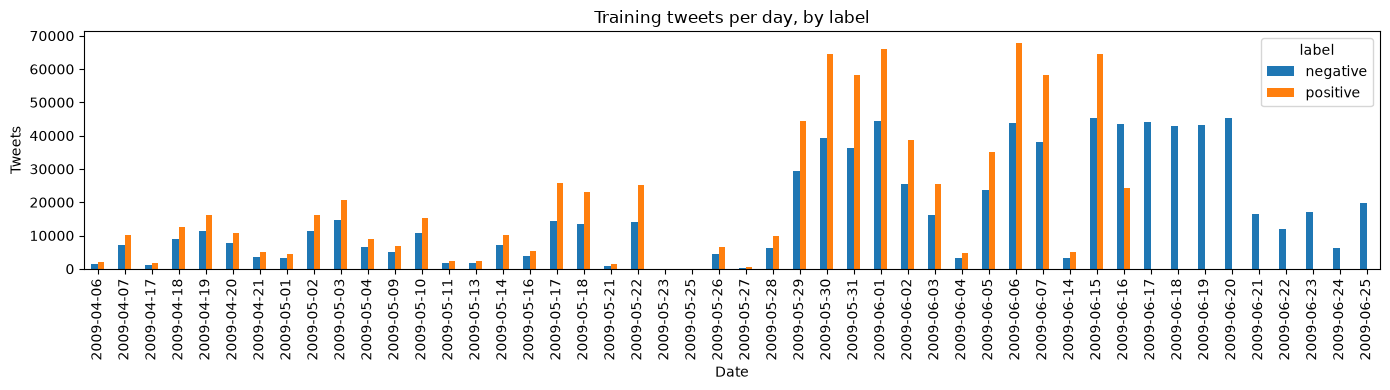

In [43]:
daily_counts = (
    train_df.groupby([train_df["created_at"].dt.date, "label"])
    .size()
    .unstack(fill_value=0)
)
daily_counts.plot(kind="bar", figsize=(14, 4), title="Training tweets per day, by label")
plt.xlabel("Date")
plt.ylabel("Tweets")
plt.tight_layout()
plt.show()


In [44]:
# How many words in the test set never appear in the training sample?
train_vocab = set(word_counts["positive"]) | set(word_counts["negative"])
test_tokens = [token for text in test_df["text"] for token in tokenize(text)]
unseen = [token for token in test_tokens if token not in train_vocab]

print(f"Test tokens not seen in the training sample: {len(unseen) / len(test_tokens):.1%}")
Counter(unseen).most_common(20)


Test tokens not seen in the training sample: 3.9%


[('malcolm', 11),
 ('gladwell', 10),
 ('flay', 8),
 ('pelosi', 5),
 ('googleio', 4),
 ('booz', 3),
 ('lambda', 3),
 ('shoreline', 3),
 ('lyx', 2),
 ('weka', 2),
 ("silverstein's", 2),
 ("warner's", 2),
 ('sandbox', 2),
 ('summize', 2),
 ("'star", 2),
 ("trek'", 2),
 ('fieri', 2),
 ('receipes', 2),
 ('loooooooovvvvvveee', 1),
 ('childs', 1)]

In [45]:
show_examples(test_df, "neutral", n=10)


- How to Track Iran with Social Media: http://bit.ly/2BoqU
- Google Wave Developer Sandbox Account Request http://bit.ly/2NYlc
- myfoxdc Barrie Students Back from Trip to China: A Silver Spring high school's class trip to China has en.. http://tinyurl.com/nlhqba
- Nike Air Yeezy Khaki/Pink Colorway Release - http://shar.es/bjfN
- Did not realize there is a gym above Safeway!
- 'Next time, I'll call myself Nike'
- is eating  home made yema
- Any twitter to aprs apps yet?
- What's Buffet Doing? Warren Buffett Kicks Butt In Battle of the Boots: Posted By:Alex Crippe.. http://bit.ly/AUIzO
- RT @jquery: The Ultimate jQuery List - http://jquerylist.com/


In [47]:
train_df["created_at"] = parse_tweet_dates(train_df["date"])

print(train_df["created_at"].min(), "to", train_df["created_at"].max())
train_df.groupby("label")["created_at"].agg(["min", "max"])


2009-04-06 22:19:45 to 2009-06-25 10:28:31


,min,max
label,,
negative,2009-04-06 22:19:45,2009-06-25 10:28:31
positive,2009-04-06 22:22:45,2009-06-16 08:40:50


In [48]:
train_df["created_at"] = parse_tweet_dates(train_df["date"])

print(train_df["created_at"].min(), "to", train_df["created_at"].max())


2009-04-06 22:19:45 to 2009-06-25 10:28:31


In [53]:
print(train_df["label"].unique())
print(test_df["label"].unique())
# test_df

<StringArray>
['negative', 'positive']
Length: 2, dtype: str
<StringArray>
['positive', 'negative', 'neutral']
Length: 3, dtype: str
